# Notebook 04 - Wide & Deep Neural Network

## Wide & Deep Model Overview

This notebook trains a Wide & Deep model for the same 3-class flight delay task. The purpose is to improve class balance and Macro F1 compared with the MLP baseline.

The model combines a wide path for direct numerical signals with a deep path that learns nonlinear interactions from embeddings and numerical features.


In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Environment and Output Folders

This section sets the project paths, output folders, and compute device used for training.


In [2]:
BASE_DIR = Path.cwd().parent

PROCESSED_DIR = BASE_DIR / "data" / "generated" / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Data Loading

We load the same metadata, category sizes, and class weights used by the MLP. This keeps the comparison between models consistent.


In [3]:
with open(PROCESSED_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

with open(PROCESSED_DIR / "category_cardinalities.json", "r") as f:
    category_cardinalities = json.load(f)

with open(PROCESSED_DIR / "class_weights.json", "r") as f:
    class_weights_dict = json.load(f)

categorical_cols = metadata["categorical_cols"]
numeric_cols = metadata["numeric_cols"]
num_classes = metadata["num_classes"]
class_names = metadata["class_names"]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numeric_cols)
print("Num classes:", num_classes)
print("Class names:", class_names)
print("Class weights dict:", class_weights_dict)

Categorical columns: ['OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_STATE_ABR', 'ROUTE', 'DEP_TIME_BLK', 'ARR_TIME_BLK']
Numerical columns: ['DISTANCE', 'CRS_DEP_MINUTES_OF_DAY', 'CRS_ARR_MINUTES_OF_DAY', 'dep_time_sin', 'dep_time_cos', 'arr_time_sin', 'arr_time_cos', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend']
Num classes: 3
Class names: {'0': 'On time', '1': 'Delay', '2': 'Long delay'}
Class weights dict: {'0': 0.42201697768504637, '1': 2.0752190993891233, '2': 6.731728574447502}


In [4]:
assert num_classes == 3, "num_classes should be 3 after target redefinition."
assert set(class_names.keys()) == {"0", "1", "2"}, "class_names should only contain classes 0, 1, and 2."
assert set(class_weights_dict.keys()) == {"0", "1", "2"}, "class_weights_dict should only contain classes 0, 1, and 2."

print("Metadata validation passed.")

Metadata validation passed.


The preprocessed train, validation, and test arrays are loaded from the files created in Notebook 02.


In [5]:
train_data = np.load(PROCESSED_DIR / "train_data.npz")
val_data = np.load(PROCESSED_DIR / "val_data.npz")
test_data = np.load(PROCESSED_DIR / "test_data.npz")

X_train_cat = train_data["X_cat"]
X_train_num = train_data["X_num"]
y_train = train_data["y"]

X_val_cat = val_data["X_cat"]
X_val_num = val_data["X_num"]
y_val = val_data["y"]

X_test_cat = test_data["X_cat"]
X_test_num = test_data["X_num"]
y_test = test_data["y"]

print("Train categorical:", X_train_cat.shape)
print("Train numerical:", X_train_num.shape)
print("Train target:", y_train.shape)

print("Validation categorical:", X_val_cat.shape)
print("Validation numerical:", X_val_num.shape)
print("Validation target:", y_val.shape)

print("Test categorical:", X_test_cat.shape)
print("Test numerical:", X_test_num.shape)
print("Test target:", y_test.shape)

Train categorical: (5128628, 8)
Train numerical: (5128628, 12)
Train target: (5128628,)
Validation categorical: (601570, 8)
Validation numerical: (601570, 12)
Validation target: (601570,)
Test categorical: (1127220, 8)
Test numerical: (1127220, 12)
Test target: (1127220,)


The PyTorch dataset and DataLoaders prepare the data for mini-batch training and evaluation.


In [6]:
class FlightDelayDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

In [7]:
batch_size = 4096

train_dataset = FlightDelayDataset(X_train_cat, X_train_num, y_train)
val_dataset = FlightDelayDataset(X_val_cat, X_val_num, y_val)
test_dataset = FlightDelayDataset(X_test_cat, X_test_num, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1253
Validation batches: 147
Test batches: 276


## Model Architecture

Embedding dimensions are created for the categorical features. These embeddings are used in the deep part of the model.


In [8]:
embedding_dims = []

for col in categorical_cols:
    cardinality = category_cardinalities[col]
    emb_dim = min(50, max(4, cardinality // 2))
    embedding_dims.append((cardinality, emb_dim))

embedding_dims

[(15, 7),
 (350, 50),
 (53, 26),
 (350, 50),
 (53, 26),
 (6688, 50),
 (20, 10),
 (20, 10)]

## Wide Path and Deep Path

The wide path uses direct numerical signals through a linear layer. The deep path combines categorical embeddings and numerical features through dense layers.

Adding the two outputs allows the model to learn both simple direct relationships and nonlinear feature interactions.


In [9]:
class WideAndDeepModel(nn.Module):
    def __init__(
        self,
        embedding_dims,
        num_numeric_features,
        num_classes,
        deep_hidden_dims=[384, 192, 96],
        dropout=0.25
    ):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=cardinality, embedding_dim=emb_dim)
            for cardinality, emb_dim in embedding_dims
        ])

        total_embedding_dim = sum(emb_dim for _, emb_dim in embedding_dims)

        # Wide path: simple direct linear signal from numerical features
        self.wide = nn.Linear(num_numeric_features, num_classes)

        # Deep path: embeddings + numerical features
        deep_input_dim = total_embedding_dim + num_numeric_features

        deep_layers = []

        input_dim = deep_input_dim

        for hidden_dim in deep_hidden_dims:
            deep_layers.append(nn.Linear(input_dim, hidden_dim))
            deep_layers.append(nn.BatchNorm1d(hidden_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        deep_layers.append(nn.Linear(input_dim, num_classes))

        self.deep = nn.Sequential(*deep_layers)

    def forward(self, x_cat, x_num):
        embedded_features = []

        for i, embedding_layer in enumerate(self.embeddings):
            embedded_features.append(embedding_layer(x_cat[:, i]))

        x_emb = torch.cat(embedded_features, dim=1)
        deep_input = torch.cat([x_emb, x_num], dim=1)

        wide_logits = self.wide(x_num)
        deep_logits = self.deep(deep_input)

        logits = wide_logits + deep_logits

        return logits

In [10]:
model = WideAndDeepModel(
    embedding_dims=embedding_dims,
    num_numeric_features=len(numeric_cols),
    num_classes=num_classes,
    deep_hidden_dims=[384, 192, 96],
    dropout=0.25
).to(device)

model

WideAndDeepModel(
  (embeddings): ModuleList(
    (0): Embedding(15, 7)
    (1): Embedding(350, 50)
    (2): Embedding(53, 26)
    (3): Embedding(350, 50)
    (4): Embedding(53, 26)
    (5): Embedding(6688, 50)
    (6-7): 2 x Embedding(20, 10)
  )
  (wide): Linear(in_features=12, out_features=3, bias=True)
  (deep): Sequential(
    (0): Linear(in_features=241, out_features=384, bias=True)
    (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=384, out_features=192, bias=True)
    (5): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=192, out_features=96, bias=True)
    (9): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.25, inplace=False)
    (12): Linear(in_features=96, out_features=

In [11]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 559711
Trainable parameters: 559711


## Training Configuration

The loss function uses controlled class weights to reduce the effect of imbalance. The optimizer and learning rate scheduler are the same general setup as the MLP for a fair comparison.


In [12]:
class_weights = np.array(
    [class_weights_dict[str(i)] for i in range(num_classes)],
    dtype=np.float32
)

class_weights = np.clip(class_weights, 0.5, 4.0)
class_weights = class_weights / class_weights.mean()

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights_tensor)

Class weights: tensor([0.2281, 0.9468, 1.8250], device='cuda:0')


In [13]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [14]:
def print_prediction_distribution(predictions, title="Prediction Distribution"):
    unique, counts = np.unique(predictions, return_counts=True)

    distribution = {
        int(k): int(v)
        for k, v in zip(unique, counts)
    }

    print(title)
    print(distribution)

## Training and Validation

The training and evaluation functions track loss, accuracy, Macro F1, and weighted F1. Validation Macro F1 is used to save the best model.


In [15]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch=None, num_epochs=None):
    model.train()

    total_loss = 0
    all_preds = []
    all_targets = []
    processed_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Training Epoch {epoch}/{num_epochs}",
        leave=True
    )

    for batch_idx, (x_cat, x_num, y) in enumerate(progress_bar):
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        batch_size_actual = y.size(0)

        processed_samples += batch_size_actual
        total_loss += loss.item() * batch_size_actual

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

        current_loss = total_loss / processed_samples
        current_progress = (processed_samples / len(dataloader.dataset)) * 100

        progress_bar.set_postfix({
            "progress": f"{current_progress:.2f}%",
            "batch_loss": f"{loss.item():.4f}",
            "avg_loss": f"{current_loss:.4f}"
        })

    avg_loss = total_loss / len(dataloader.dataset)

    accuracy = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    return avg_loss, accuracy, macro_f1, weighted_f1

In [16]:
def evaluate_model(model, dataloader, criterion, device, split_name="Validation"):
    model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []
    processed_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Evaluating {split_name}",
        leave=True
    )

    with torch.no_grad():
        for batch_idx, (x_cat, x_num, y) in enumerate(progress_bar):
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y = y.to(device)

            outputs = model(x_cat, x_num)
            loss = criterion(outputs, y)

            batch_size_actual = y.size(0)

            processed_samples += batch_size_actual
            total_loss += loss.item() * batch_size_actual

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

            current_loss = total_loss / processed_samples
            current_progress = (processed_samples / len(dataloader.dataset)) * 100

            progress_bar.set_postfix({
                "progress": f"{current_progress:.2f}%",
                "batch_loss": f"{loss.item():.4f}",
                "avg_loss": f"{current_loss:.4f}"
            })

    avg_loss = total_loss / len(dataloader.dataset)

    accuracy = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    return avg_loss, accuracy, macro_f1, weighted_f1, np.array(all_targets), np.array(all_preds)

The main training loop runs the Wide & Deep model and stops if validation Macro F1 does not improve for several epochs.


In [17]:
num_epochs = 15

best_val_macro_f1 = 0
best_model_path = MODELS_DIR / "wide_deep_best.pt"

patience = 4
epochs_without_improvement = 0

history = []

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()

    print(f"\nStarting epoch {epoch}/{num_epochs}")
    print("-" * 100)

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
        epoch=epoch,
        num_epochs=num_epochs
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1, y_true_val, y_pred_val = evaluate_model(
        model,
        val_loader,
        criterion,
        device,
        split_name="Validation"
    )

    print_prediction_distribution(
        y_pred_val,
        "Validation Prediction Distribution"
    )

    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "epoch_time_seconds": epoch_time
    })

    print(f"\nEpoch {epoch}/{num_epochs} completed")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_macro_f1:.4f} | Train Weighted F1: {train_weighted_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Macro F1:   {val_macro_f1:.4f} | Val Weighted F1:   {val_weighted_f1:.4f}")
    print(f"Epoch time: {epoch_time:.2f} seconds")
    print("-" * 100)

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "embedding_dims": embedding_dims,
            "numeric_cols": numeric_cols,
            "categorical_cols": categorical_cols,
            "num_classes": num_classes,
            "best_val_macro_f1": best_val_macro_f1,
            "epoch": epoch,
            "deep_hidden_dims": [384, 192, 96],
            "dropout": 0.25
        }, best_model_path)

        print(f"Best model saved with Val Macro F1: {best_val_macro_f1:.4f}")

    else:
        epochs_without_improvement += 1

        print(f"No improvement for {epochs_without_improvement} epoch(s)")

        if epochs_without_improvement >= patience:
            print("Early stopping triggered")
            break

total_training_time = time.time() - start_time

print("\nTraining completed")
print(f"Total training time: {total_training_time:.2f} seconds")
print(f"Best validation Macro F1: {best_val_macro_f1:.4f}")


Starting epoch 1/15
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 147/147 [00:07<00:00, 19.64it/s, progress=100.00%, batch_loss=1.2461, avg_loss=0.9771]


Validation Prediction Distribution
{0: 528730, 1: 72817, 2: 23}

Epoch 1/15 completed
Train Loss: 1.0000 | Train Acc: 0.6357 | Train Macro F1: 0.4063 | Train Weighted F1: 0.6660
Val Loss:   0.9771 | Val Acc:   0.7614 | Val Macro F1:   0.3702 | Val Weighted F1:   0.7338
Epoch time: 102.06 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.3702

Starting epoch 2/15
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 147/147 [00:07<00:00, 20.66it/s, progress=100.00%, batch_loss=1.2731, avg_loss=0.9807]


Validation Prediction Distribution
{0: 538209, 1: 63250, 2: 111}

Epoch 2/15 completed
Train Loss: 0.9818 | Train Acc: 0.6462 | Train Macro F1: 0.4240 | Train Weighted F1: 0.6761
Val Loss:   0.9807 | Val Acc:   0.7718 | Val Macro F1:   0.3717 | Val Weighted F1:   0.7390
Epoch time: 100.60 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.3717

Starting epoch 3/15
----------------------------------------------------------------------------------------------------


...

Validation Prediction Distribution
{0: 510221, 1: 82530, 2: 8819}

Epoch 13/15 completed
Train Loss: 0.9464 | Train Acc: 0.6485 | Train Macro F1: 0.4491 | Train Weighted F1: 0.6823
Val Loss:   0.9926 | Val Acc:   0.7529 | Val Macro F1:   0.3963 | Val Weighted F1:   0.7376
Epoch time: 99.33 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.3963

Starting epoch 14/15
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 147/147 [00:06<00:00, 22.03it/s, progress=100.00%, batch_loss=1.3487, avg_loss=0.9960]


Validation Prediction Distribution
{0: 510476, 1: 82293, 2: 8801}

Epoch 14/15 completed
Train Loss: 0.9449 | Train Acc: 0.6484 | Train Macro F1: 0.4495 | Train Weighted F1: 0.6823
Val Loss:   0.9960 | Val Acc:   0.7528 | Val Macro F1:   0.3956 | Val Weighted F1:   0.7373
Epoch time: 94.89 seconds
----------------------------------------------------------------------------------------------------
No improvement for 1 epoch(s)

Starting epoch 15/15
----------------------------------------------------------------------------------------------------


Evaluating Validation: 100%|██████████| 147/147 [00:06<00:00, 21.76it/s, progress=100.00%, batch_loss=1.3489, avg_loss=0.9960]


Validation Prediction Distribution
{0: 510924, 1: 81259, 2: 9387}

Epoch 15/15 completed
Train Loss: 0.9447 | Train Acc: 0.6486 | Train Macro F1: 0.4502 | Train Weighted F1: 0.6826
Val Loss:   0.9960 | Val Acc:   0.7531 | Val Macro F1:   0.3961 | Val Weighted F1:   0.7376
Epoch time: 93.80 seconds
----------------------------------------------------------------------------------------------------
No improvement for 2 epoch(s)

Training completed
Total training time: 1504.22 seconds
Best validation Macro F1: 0.3963


The training history is saved and plotted to check the behavior of loss and Macro F1 over time.


In [18]:
history_df = pd.DataFrame(history)

history_path = RESULTS_DIR / "wide_deep_training_history.csv"
history_df.to_csv(history_path, index=False)

history_df

,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,epoch_time_seconds
0,1,1.000046,0.635672,0.406263,0.665971,0.977149,0.761374,0.370165,0.733760,102.057207
1,2,0.981834,0.646238,0.424003,0.676110,0.980678,0.771844,0.371661,0.738982,100.603514
2,3,0.975254,0.647526,0.430108,0.678160,0.978184,0.770635,0.376033,0.740300,100.251463
3,4,0.970036,0.648445,0.434455,0.679619,0.978414,0.764822,0.382502,0.740571,106.867556
4,5,0.963252,0.649219,0.439578,0.681094,0.978510,0.759453,0.386117,0.739509,105.367444
5,6,0.959952,0.649116,0.441598,0.681394,0.981331,0.759735,0.389078,0.740006,104.026902
6,7,0.957460,0.648874,0.442928,0.681492,0.985626,0.754685,0.390359,0.737455,99.814551
7,8,0.953510,0.649316,0.445510,0.682210,0.991186,0.761866,0.389804,0.739973,98.544853
8,9,0.951723,0.648812,0.446378,0.682064,0.989612,0.758814,0.392041,0.739342,100.624717
9,10,0.950244,0.649079,0.447532,0.682404,0.987488,0.751529,0.396331,0.737169,99.845040


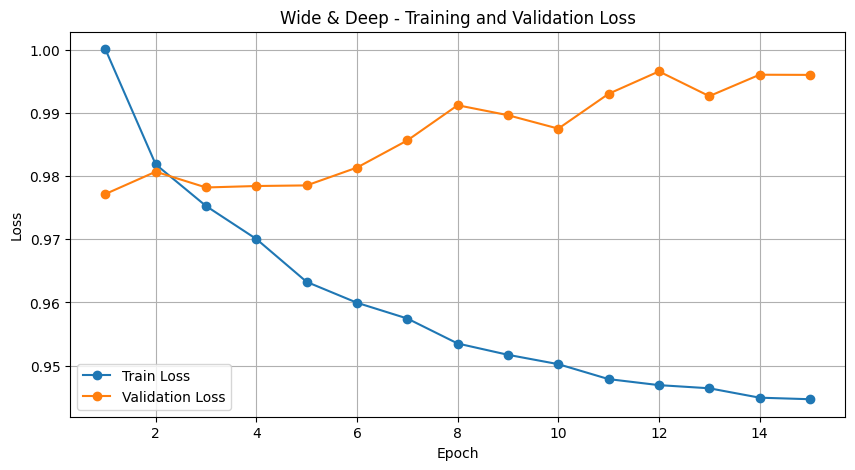

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Wide & Deep - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

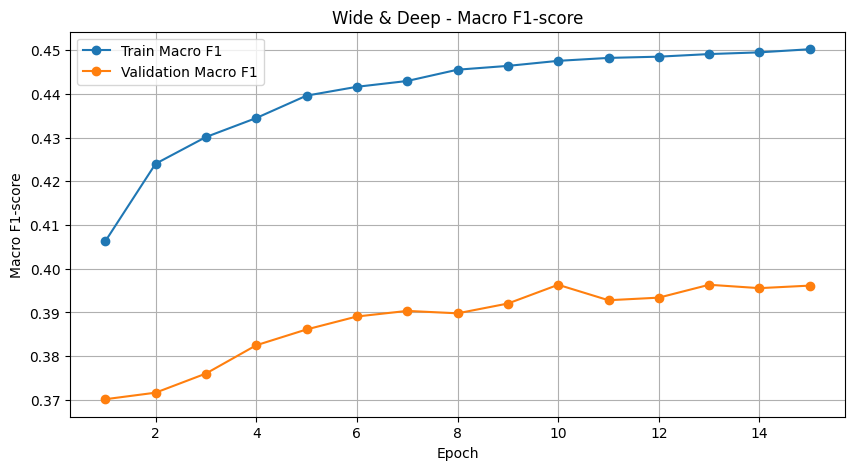

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Wide & Deep - Macro F1-score")
plt.legend()
plt.grid(True)
plt.show()

## Test Evaluation

The best validation checkpoint is loaded and evaluated on the test months. This gives the final performance for the Wide & Deep model.


In [21]:
checkpoint = torch.load(best_model_path, map_location=device)

best_model = WideAndDeepModel(
    embedding_dims=checkpoint["embedding_dims"],
    num_numeric_features=len(checkpoint["numeric_cols"]),
    num_classes=checkpoint["num_classes"],
    deep_hidden_dims=checkpoint["deep_hidden_dims"],
    dropout=checkpoint["dropout"]
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])

print("Best model loaded")
print("Best validation Macro F1:", checkpoint["best_val_macro_f1"])
print("Best epoch:", checkpoint["epoch"])

Best model loaded
Best validation Macro F1: 0.3963337859425087
Best epoch: 13


C:\Users\of_de\AppData\Local\Temp\ipykernel_20212\2250429404.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device

In [22]:
test_loss, test_acc, test_macro_f1, test_weighted_f1, y_true, y_pred = evaluate_model(
    best_model,
    test_loader,
    criterion,
    device,
    split_name="Test"
)

print("Test results")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))
print("Test macro F1:", round(test_macro_f1, 4))
print("Test weighted F1:", round(test_weighted_f1, 4))

print_prediction_distribution(
    y_pred,
    "Test Prediction Distribution"
)

Evaluating Test: 100%|██████████| 276/276 [00:13<00:00, 20.19it/s, progress=100.00%, batch_loss=1.2262, avg_loss=1.0411]


Test results
Test loss: 1.0411
Test accuracy: 0.6977
Test macro F1: 0.3765
Test weighted F1: 0.6806
Test Prediction Distribution
{0: 918208, 1: 194863, 2: 14149}


Compared with the MLP, this model gives a higher Macro F1 while accuracy decreases. This means the predictions are more balanced across the classes.


## Per-Class Performance

The classification report shows precision, recall, and F1 for each class. This is important because the goal is not only high accuracy but also better detection of delayed flights.


In [23]:
target_names = [class_names[str(i)] for i in range(num_classes)]

report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     On time       0.80      0.85      0.82    867712
       Delay       0.26      0.26      0.26    197309
  Long delay       0.14      0.03      0.05     62199

    accuracy                           0.70   1127220
   macro avg       0.40      0.38      0.38   1127220
weighted avg       0.67      0.70      0.68   1127220



The report shows that the Wide & Deep model predicts `Delay` and `Long delay` more often than the MLP. Long-delay performance is still limited, but the model is less focused only on the majority class.


In [24]:
with open(RESULTS_DIR / "wide_deep_classification_report.txt", "w") as f:
    f.write(report)

In [25]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

cm_df

,On time,Delay,Long delay
On time,734110,124444,9158
Delay,143821,50417,3071
Long delay,40277,20002,1920


The confusion matrix supports the same conclusion: more minority-class flights are detected, although many are still confused with the on-time class.


In [26]:
cm_df.to_csv(RESULTS_DIR / "wide_deep_confusion_matrix.csv")

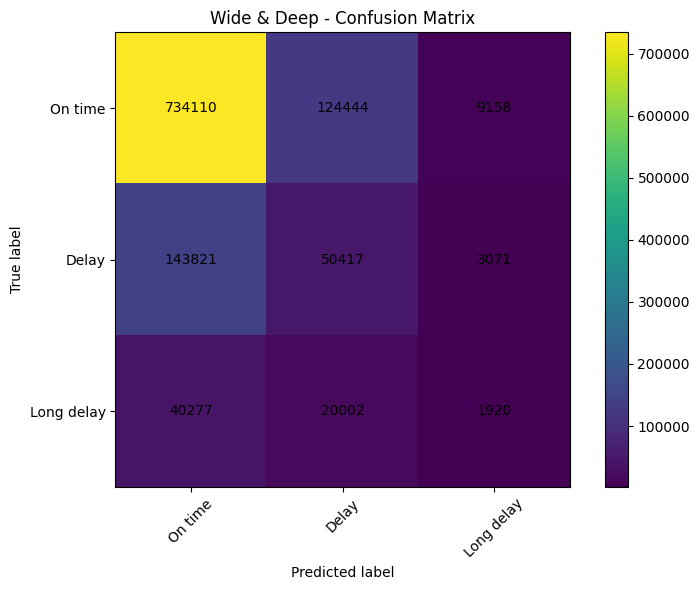

In [27]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Wide & Deep - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(num_classes), target_names, rotation=45)
plt.yticks(np.arange(num_classes), target_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

The result dictionary saves the model metrics and architecture details so they can be compared with the MLP and TabTransformer.


In [28]:
wide_deep_results = {
    "model_name": "Wide & Deep Neural Network",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "best_val_macro_f1": float(best_val_macro_f1),
    "total_training_time_seconds": float(total_training_time),
    "num_epochs": int(len(history_df)),
    "batch_size": batch_size,
    "optimizer": "AdamW",
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "loss_function": "CrossEntropyLoss with controlled class weights",
    "architecture": {
        "embedding_dims": embedding_dims,
        "deep_hidden_dims": [384, 192, 96],
        "dropout": 0.25,
        "num_numeric_features": len(numeric_cols),
        "num_categorical_features": len(categorical_cols),
        "num_classes": num_classes,
        "wide_path": "Linear layer over numerical features",
        "deep_path": "Categorical embeddings + numerical features through MLP",
        "final_combination": "wide_logits + deep_logits"
    }
}

with open(RESULTS_DIR / "wide_deep_results.json", "w") as f:
    json.dump(wide_deep_results, f, indent=4)

wide_deep_results

{'model_name': 'Wide & Deep Neural Network',
 'test_loss': 1.0411195801528677,
 'test_accuracy': 0.6976872305317506,
 'test_macro_f1': 0.37650709379573505,
 'test_weighted_f1': 0.680624208490369,
 'best_val_macro_f1': 0.3963337859425087,
 'total_training_time_seconds': 1504.2191035747528,
 'num_epochs': 15,
 'batch_size': 4096,
 'optimizer': 'AdamW',
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'loss_function': 'CrossEntropyLoss with controlled class weights',
 'architecture': {'embedding_dims': [(15, 7),
   (350, 50),
   (53, 26),
   (350, 50),
   (53, 26),
   (6688, 50),
   (20, 10),
   (20, 10)],
  'deep_hidden_dims': [384, 192, 96],
  'dropout': 0.25,
  'num_numeric_features': 12,
  'num_categorical_features': 8,
  'num_classes': 3,
  'wide_path': 'Linear layer over numerical features',
  'deep_path': 'Categorical embeddings + numerical features through MLP',
  'final_combination': 'wide_logits + deep_logits'}}

In [29]:
print("Notebook 04 completed")
print("Model: Wide & Deep Neural Network")

print("\nSaved files:")
print(best_model_path)
print(RESULTS_DIR / "wide_deep_training_history.csv")
print(RESULTS_DIR / "wide_deep_classification_report.txt")
print(RESULTS_DIR / "wide_deep_confusion_matrix.csv")
print(RESULTS_DIR / "wide_deep_results.json")

print("\nFinal Test Metrics:")
print(f"Accuracy:    {test_acc:.4f}")
print(f"Macro F1:    {test_macro_f1:.4f}")
print(f"Weighted F1: {test_weighted_f1:.4f}")

Notebook 04 completed
Model: Wide & Deep Neural Network

Saved files:
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\models\wide_deep_best.pt
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\wide_deep_training_history.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\wide_deep_classification_report.txt
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\wide_deep_confusion_matrix.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\wide_deep_results.json

Final Test Metrics:
Accuracy:    0.6977
Macro F1:    0.3765
Weighted F1: 0.6806


## Wide & Deep Model Conclusion

The Wide & Deep model improves Macro F1 compared with the MLP baseline. The lower accuracy is acceptable in this context because the model gives more attention to the delayed classes.
